In [8]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

from figure_utils import (
    build_model_palette,
    format_model_str_word_task,
    marker_palette_for_hue,
    normalize_model_list,
    normalize_model_name,
    normalize_palette_dict,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    get_plot_groups,
    model_label,
    plot_grouped_bars,
)

# Get SpeechCommands results

In [9]:
def format_model_str_sc_task(path):
    path_str = str(path)
    eq_lmbda = ''
    if 'eq_lmbda' in path_str:
        eq_lmbda = re.search(r'eq_lmbda_([-\d.e]+)', path_str).group(1)
        if float(eq_lmbda) == 0:
            eq_lmbda = ''
        else:
            eq_lmbda = ' ' + eq_lmbda

    task = ''
    if 'dualtask' in path_str or 'equivariant' in path_str or (eq_lmbda != '' and float(eq_lmbda) != 0):
        task = 'ssl'
    else:
        task = 'invariant'
    if '_dual_' in path_str:
        task = f"dual {task}"
    if 'audioset' in path_str:
        task = 'supervised audioset'
    if 'word' in path_str and not 'barlow' in path_str:
        task = 'supervised word'
    if 'word_speaker_audioset' in path_str:
        task = 'supervised multi-task'
        
    arch = 'kell2018'

    if "resnet" in path_str:
        arch = 'resnet' + re.search(r'resnet([-\d]+)', path_str).group(1)
    
    if 'config' in path_str:
        arch = 'byol-a'
        task = ''
        

    test_layer = path_str.split('AdamW_')[-1].split('_')[0]
    
    aug_str = ''
    if 'resnet18' in path_str and not 'w_invar_aug' in path_str:
        aug_str = ' paired augmentations'
    model_name = f"{arch} {task}{eq_lmbda}{aug_str}"
    if arch == 'byol-a':
        model_name = model_name.replace('byol-a ', 'byol-a')
    return model_name, arch, test_layer, eq_lmbda

In [ ]:
path_to_speech_commands_results = Path("eval_jsin_results/linear_eval_speech_commands")
kell2018_speech_commands_results = list(path_to_speech_commands_results.rglob("*kell2018*full*cosine*.pkl"))
kell2018_speech_commands_results = [path for path in kell2018_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'mmcr']])]

resnet18_speech_commands_results = list(path_to_speech_commands_results.rglob("resnet18*.pkl"))
resnet18_speech_commands_results = [path for path in resnet18_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop']])]

byola_results =  list(path_to_speech_commands_results.rglob("config_*cosine*.pkl"))

all_speech_commands_task_results = kell2018_speech_commands_results + resnet18_speech_commands_results + byola_results

df_list = []

for i, results_path in enumerate(all_speech_commands_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if "equivariant" in path_str and not "cosine" in path_str:
        continue 


    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, _, eq_lmbda = format_model_str_word_task(results_path)
    if arch_class == 'unknown' and 'config_' in path_str:
        model_name = 'byol-a'
        arch_class = 'byol-a'
        eq_lmbda = ''
        print(model_name, arch_class, eq_lmbda)
    
    # Remove audioset modifiers before normalization if we have explicit eq_lmbda
    # to prevent normalize_model_name from adding another lambda
    if eq_lmbda and 'ssl' in model_name:
        model_name = re.sub(
            r'\s+(?:jsin\s+)?audioset|\s+unbalanced\s+audioset',
            '',
            model_name,
        )
        model_name = re.sub(r'\s{2,}', ' ', model_name).strip()
    
    # Normalize the model name
    model_name = normalize_model_name(model_name)
    
    test_layer = path_str.split('AdamW_')[-1].split('_')[0]
    if model_name == 'byol-a':
        test_layer = 'final'

    data = dict(model_name=model_name, results_path=results_path.stem, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}


    df_list.append(data)

speech_commands_df = pd.DataFrame.from_records(df_list)
speech_commands_df['test_layer'] = speech_commands_df['test_layer'].astype('str')
speech_commands_df['task'] = '20-word classification'

byol-a byol-a 


In [21]:
speech_commands_df

,model_name,results_path,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,word_top5_mean,word_top5_sem,task
0,CochCNN9 supervised word,word_kell2018_MatchedDataset_LARS_AdamW_relu4_...,kell2018,relu4,,0.919832,0.011106,0.976736,0.008816,20-word classification
1,CochCNN9 scaled ssl λ=0.5,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,kell2018,relu4,0.5,0.829391,0.017448,0.971793,0.005095,20-word classification
2,CochCNN9 scaled supervised,kell2018_audioset_unbalanced_supervised_AdamW_...,kell2018,relu4,,0.788480,0.021008,0.965053,0.006116,20-word classification
3,CochCNN9 ssl λ=0.3,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,kell2018,relu4,0.3,0.839114,0.013614,0.977145,0.004770,20-word classification
4,CochCNN9 ssl λ=0.5,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,kell2018,relu4,0.5,0.833293,0.013590,0.979922,0.004403,20-word classification
5,CochCNN9 scaled ssl λ=0.0,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,kell2018,relu4,0.0,0.834457,0.013127,0.974163,0.005106,20-word classification
6,CochCNN9 ssl λ=0.4,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,kell2018,relu4,0.4,0.840441,0.013692,0.976797,0.003599,20-word classification
7,CochCNN9 ssl λ=0.1,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,kell2018,relu4,0.1,0.845445,0.013321,0.980065,0.004825,20-word classification
8,CochCNN9 supervised multi-task,kell2018_word_speaker_audioset_MatchedDataset_...,kell2018,relu4,,0.939073,0.007331,0.981250,0.007432,20-word classification
9,CochCNN9 supervised audioset,audioset_kell2018_MatchedDataset_LARS_AdamW_re...,kell2018,relu4,,0.743730,0.014933,0.951654,0.009741,20-word classification


In [22]:
screen = speech_commands_df.results_path.str.contains('barlow_word_kell')
speech_commands_df[screen].results_path.values, speech_commands_df[screen].word_top1_mean

(array(['barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_AdamW_relu4_full_rep_0.01_cosine_lr_scheduler__from_best_val_ckpt'],
       dtype=object),
 10    0.848141
 Name: word_top1_mean, dtype: float64)

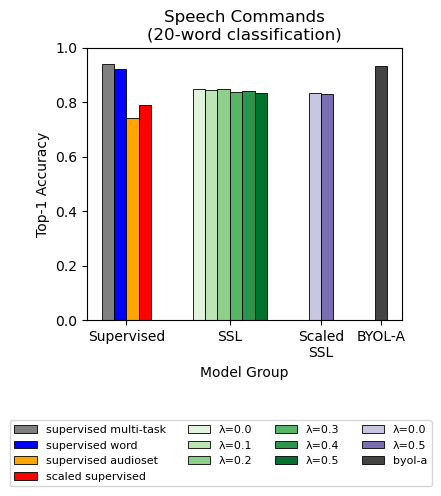

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re

# Filter data for relu4 and final layers
speech_commands_to_plot = speech_commands_df[
    speech_commands_df.test_layer.isin(["relu4", "final"])
].copy()

# Get standardized hue order and colors
hue_order = get_standard_hue_order()
marker_palette = marker_palette_for_hue(hue_order)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

# Get model groups (for legend handling)
supervised_names, ssl_names, scaled_ssl_names, byol_names = get_model_groups(hue_order)


# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

handles, labels = plot_grouped_bars(
    ax,
    speech_commands_to_plot,
    value_col='word_top1_mean',
    title='Speech Commands\n(20-word classification)',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)
ax.set_ylim(0, 1.0)

# Build legend
legend_handles = []
legend_labels = []
for handle, label in zip(handles, labels):
    # if label not in legend_labels:
    legend_handles.append(handle)
    legend_labels.append(label)

# Ensure scaled SSL palette entries appear in legend, even if missing from data
for model in scaled_ssl_names:
    label = model_label(model)
    if label not in legend_labels:
        color = hue_dict.get(model, '#444444')
        legend_handles.append(Patch(facecolor=color, edgecolor='black'))
        legend_labels.append(label)

if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
    )

plt.tight_layout()
plt.show()